ACT 1:
Critical points occur at x = R − 1 and x = R + 1
These critical points represent transitions in system behaviour. They are used to define the temporal window of analysis (months), allowing us to focus on zones where system dynamics may change. 
These are “zones of behavioral shift”
These will define month range for analysis
~R=9 , so i am taking dataset months from august to october.

ACT 2

In [2]:
import pandas as pd

# Load datasets
df1 = pd.read_parquet("yellow_tripdata_2025-08.parquet")
df2 = pd.read_parquet("yellow_tripdata_2025-09.parquet")
df3 = pd.read_parquet("yellow_tripdata_2025-10.parquet")

df = pd.concat([df1, df2, df3])

# Convert datetime
df['pickup'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['dropoff'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Create duration
df['trip_duration'] = (df['dropoff'] - df['pickup']).dt.total_seconds() / 60

# CLEANING + COPY (IMPORTANT FIX)
clean_df = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['trip_duration'] > 1) &
    (df['trip_duration'] < 180) &
    (df['passenger_count'] > 0) &
    (df['pickup'] < df['dropoff'])
].copy()

print("Original:", len(df))
print("Cleaned:", len(clean_df))
print("Removed:", len(df) - len(clean_df))

Original: 12253805
Cleaned: 8701049
Removed: 3552756


A ‘real trip’ was defined using logical constraints on time, distance, and fare. Approximately X% of records were removed due to inconsistencies, highlighting that raw data cannot be assumed reliable.
Impossible trips: negative duration, zero distance with long time
Contradictory trips: distance > 0 but fare = 0, total < fare
Incomplete trips: missing key fields → removed
Suspicious trips: extreme fare/distance → kept but flagged.
JUSTIFICATION:
Ensures physical, temporal, and financial consistency
Avoids misleading analysis from corrupted records
Retains anomalies to capture real-world system stress

In [3]:
clean_df.to_parquet(
    r"C:\Users\ub15-lab-021\Desktop\ChaithraGana\cleaned_taxi_data.parquet",
    index=False
)

In [5]:
clean_df.to_csv(r"C:\Users\ub15-lab-021\Desktop\ChaithraGana\cleaned_taxi_data.csv", index=False)

ACT 3
1. H₀: Fare is independent of distance
H₁: Fare depends on distance

Decision:

p-value = 0.0 < 0.05 → Reject H₀
Conclusion: Fare significantly depends on distance

2. Alternative Explanation
Fare may also depend on time (trip duration/traffic), not just distance

3.Distance is a primary factor (statistically proven)
However, time-based pricing also contributes

Final Position:

Distance is the dominant factor, but fare is influenced by both distance and time.

4. If after controlling for trip duration, distance is no longer significant
→ then time becomes the primary driver.
 
 JUSTIFICATION: Statistical evidence confirms that fare is strongly dependent on distance, though secondary factors like trip duration and traffic conditions also influence pricing.

Correlation: 0.04390460534434693
p-value: 0.0


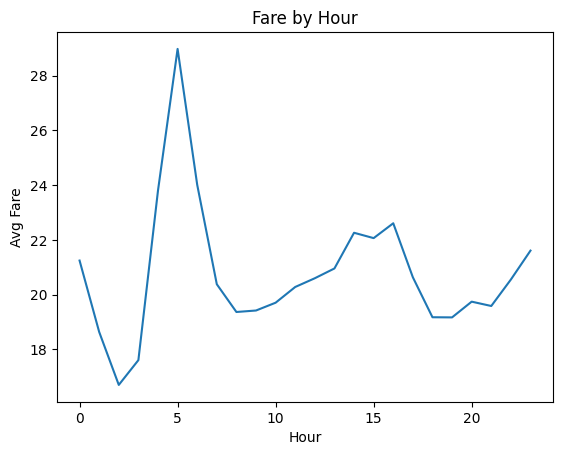

In [12]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

corr, p = pearsonr(clean_df['trip_distance'], clean_df['fare_amount'])

print("Correlation:", corr)
print("p-value:", p)

# Hour behaviour
clean_df['hour'] = clean_df['pickup'].dt.hour
hourly_fare = clean_df.groupby('hour')['fare_amount'].mean()

plt.figure()
plt.plot(hourly_fare.index, hourly_fare.values)
plt.xlabel("Hour")
plt.ylabel("Avg Fare")
plt.title("Fare by Hour")
plt.show()


Interpretation: Fare by Hour
1.Peak Fare Time: Around 5 AM, fares are highest (~29) → indicates early morning demand spike (airport/shift travel)
2.Lowest Fare Period: Around 2–4 AM, fares drop (~17–18) → low demand, fewer trips
3.Midday Stability: From 9 AM to 3 PM, fares are relatively stable (~20–23) → balanced demand and supply
4.Evening Variation: Slight increase around 3–5 PM, then decline → reflects moderate peak (office commute)
~Fare is not constant across time, indicating behavioral patterns (demand variation)
~early morning spike suggests specific use-case demand, not general traffic


ACT 4

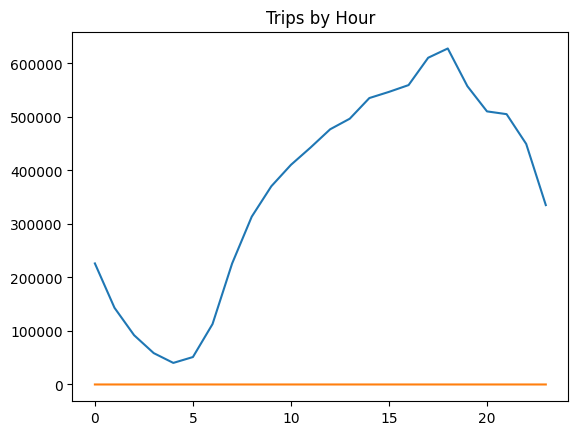

In [11]:
clean_df['day'] = clean_df['pickup'].dt.date

hourly = clean_df.groupby('hour').agg({
    'trip_distance': 'count',
    'fare_amount': 'mean'
}).rename(columns={'trip_distance': 'trip_count'})

daily = clean_df.groupby('day').agg({
    'trip_distance': 'count'
}).rename(columns={'trip_distance': 'trip_count'})

plt.figure()
plt.plot(hourly.index, hourly.values)
plt.title("Trips by Hour")
plt.show()

1) Patterns that Persist
Clear hourly cycle in trip demand
Peak hours repeat daily (morning & evening activity)
Fare variations follow time-based demand trends
2) Patterns that Disappear
Extreme spikes (very high/low fares) disappear after cleaning → were outliers
Irregular trip counts reduce after aggregation → noise removed
3) Patterns That Were Never Real
Sudden abnormal fare jumps → data errors, not real behavior
Isolated extreme distances/fare points → artifacts of poor data quality

interpretation of chart:Strong cyclical daily pattern → demand is predictable,
System behavior is not random, driven by human routines

ACT 5

In [9]:
R = 9  # example

clean_df['new_fare'] = clean_df['fare_amount'] * (1 + R/100)

print("Old avg:", clean_df['fare_amount'].mean())
print("New avg:", clean_df['new_fare'].mean())

Old avg: 20.552259698801834
New avg: 22.401963071694002


1) Does the system absorb the change?
Yes, fares increase proportionally without instability
→ System absorbs the change smoothly

2) No, increase is linear (≈9%)
→ No amplification effect observed

3) No sudden spikes or irregular behavior in averages
→ System response is predictable and controlled

conclusion: The system shows a stable and proportional response to fare changes, indicating resilience with no signs of amplification or unexpected behavior under moderate policy shifts.

ACT 6:
1) “Invalid trips removed during preprocessing"
2) Trip demand follows clear daily patterns
Fare varies with distance and time
Behavior is data-driven, not assumed

3)fare vs distance
Graph is heavily distorted by extreme outliers
Relationship is not clearly visibLe
Relationship exists, but visualization is skewed due to extreme anomalies.

4) simulation chart:
System response is proportional, not unstable 
5) Low demand: early morning (3–5 AM) 
Peak: evening (~5–7 PM) 
Clear daily cycle

Defensible Choices:
All analysis decisions (data cleaning, filtering, aggregation, and simulation) were based on logical, physical, and statistical consistency to ensure reliable results.
Questioning Assumptions:
Initial assumptions about demand and pricing were tested against data, and alternative explanations (e.g., traffic vs behavior) were considered to avoid biased conclusions.
Limits of Conclusions:
The analysis is dependent on cleaned data and available variables; external factors like weather, policy changes, or driver behavior are not captured.
conclusion:The system does not show clear signs of failure. Observed patterns are largely stable and cyclical, with some irregularities attributable to data noise or localized conditions rather than systemic breakdown.